# 01 - Data Preprocessing for Toxicity Prediction

This notebook handles the complete data preprocessing pipeline for the SSL-GCN toxicity prediction project.

**Key Steps:**
1. Load Tox21 dataset from CSV files
2. Perform scaffold-based splitting (80% train, 10% val, 10% test)
3. Generate ECFP4 fingerprints for baseline models
4. Convert molecules to graph representations for GCN
5. Cache processed data for efficient training

**Dataset:** 12 toxicity endpoints from Tox21 challenge

In [24]:

import os
import sys
import pandas as pd
import numpy as np
import pickle
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


sys.path.insert(0, os.path.abspath('../src'))


from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold


import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns



In [ ]:

DATA_DIR = '../Data/csv'
CACHE_DIR = '../Data/cache'


TOXICITY_ENDPOINTS = [
    'NR-AhR', 'NR-AR', 'NR-AR-LBD', 'NR-Aromatase',
    'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]


TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1


ECFP_RADIUS = 2  
ECFP_BITS = 2048 



Configuration loaded:
  - Data directory: ../Data/csv
  - Toxicity endpoints: 12
  - Split ratios: 0.8/0.1/0.1


## 1. Load and Explore Dataset

Load CSV files for each toxicity endpoint and examine the data structure.

In [26]:

def load_dataset(toxicity_name):
    """Load a single toxicity dataset from CSV."""
    csv_path = os.path.join(DATA_DIR, f"{toxicity_name}.csv")
    df = pd.read_csv(csv_path)
    return df


dataset_summary = []
for endpoint in TOXICITY_ENDPOINTS:
    df = load_dataset(endpoint)
    df_clean = df.dropna(subset=[endpoint])

    total = len(df_clean)
    pos_count = (df_clean[endpoint] == 1).sum()
    neg_count = (df_clean[endpoint] == 0).sum()
    pos_rate = pos_count / total if total else 0.0
    neg_rate = neg_count / total if total else 0.0
    imbalance_ratio = (neg_count / pos_count) if pos_count else np.nan

    dataset_summary.append({
        'Endpoint': endpoint,
        'Total': total,
        'Positive': pos_count,
        'Negative': neg_count,
        'Positive_Rate': pos_rate,
        'Negative_Rate': neg_rate,
        'Imbalance_Ratio': imbalance_ratio
    })

summary_df = pd.DataFrame(dataset_summary)

summary_print = summary_df[['Endpoint', 'Total', 'Positive', 'Negative', 'Positive_Rate', 'Imbalance_Ratio']].copy()
summary_print['Positive_Rate'] = summary_print['Positive_Rate'] * 100

print("Dataset Summary (sorted by positive rate):")
print(
    summary_print.sort_values('Positive_Rate').to_string(
        index=False,
        formatters={
            'Positive_Rate': lambda x: f"{x:.1f}%",
            'Imbalance_Ratio': lambda x: "∞" if (pd.isna(x) or not np.isfinite(x)) else f"{x:.1f}x"
        }
    )
)

Dataset Summary (sorted by positive rate):
     Endpoint  Total  Positive  Negative Positive_Rate Imbalance_Ratio
NR-PPAR-gamma   6450       186      6264          2.9%           33.7x
    NR-AR-LBD   6758       237      6521          3.5%           27.5x
     SR-ATAD5   7072       264      6808          3.7%           25.8x
        NR-AR   7265       309      6956          4.3%           22.5x
    NR-ER-LBD   6955       350      6605          5.0%           18.9x
 NR-Aromatase   5821       300      5521          5.2%           18.4x
       SR-HSE   6467       372      6095          5.8%           16.4x
       SR-p53   6774       423      6351          6.2%           15.0x
       NR-AhR   6549       768      5781         11.7%            7.5x
        NR-ER   6193       793      5400         12.8%            6.8x
       SR-MMP   5810       918      4892         15.8%            5.3x
       SR-ARE   5832       942      4890         16.2%            5.2x


### Class Imbalance Diagnostics
 
The Tox21 endpoints have unequal numbers of toxic vs. non-toxic labels. The following quick EDA block surfaces the degree of imbalance upfront so we can plan resampling or weighting strategies before modeling.

In [ ]:

imbalance_view = (
    summary_df[['Endpoint', 'Total', 'Positive', 'Negative', 'Positive_Rate', 'Negative_Rate', 'Imbalance_Ratio']]
    .sort_values('Positive_Rate')
    .reset_index(drop=True)
    .assign(
        Positive_Pct=lambda df: df['Positive_Rate'] * 100,
        Negative_Pct=lambda df: df['Negative_Rate'] * 100,
    )
)

def _format_ratio(val):
    if pd.isna(val) or not np.isfinite(val):
        return "∞"
    return f"{val:.1f}x"


print("\n" + "="*90)
print("CLASS IMBALANCE TABLE (sorted by positive rate)")
print("="*90)
display_df = imbalance_view[['Endpoint', 'Total', 'Positive', 'Negative', 'Positive_Pct', 'Negative_Pct', 'Imbalance_Ratio']].copy()
print(display_df.to_string(
    index=False,
    formatters={
        'Positive_Pct': lambda x: f"{x:.1f}%",
        'Negative_Pct': lambda x: f"{x:.1f}%",
        'Imbalance_Ratio': _format_ratio
    }
))


# Statistical summary of imbalance

print("IMBALANCE STATISTICS")

print(f"Mean positive rate: {imbalance_view['Positive_Pct'].mean():.2f}%")
print(f"Median positive rate: {imbalance_view['Positive_Pct'].median():.2f}%")
print(f"Std dev positive rate: {imbalance_view['Positive_Pct'].std():.2f}%")
print(f"Min positive rate: {imbalance_view['Positive_Pct'].min():.2f}% ({imbalance_view.loc[imbalance_view['Positive_Pct'].idxmin(), 'Endpoint']})")
print(f"Max positive rate: {imbalance_view['Positive_Pct'].max():.2f}% ({imbalance_view.loc[imbalance_view['Positive_Pct'].idxmax(), 'Endpoint']})")

# Categorize severity
severely_imbalanced = imbalance_view[imbalance_view['Positive_Pct'] < 10]['Endpoint'].tolist()
moderately_imbalanced = imbalance_view[(imbalance_view['Positive_Pct'] >= 10) & (imbalance_view['Positive_Pct'] < 20)]['Endpoint'].tolist()
mildly_imbalanced = imbalance_view[imbalance_view['Positive_Pct'] >= 20]['Endpoint'].tolist()






CLASS IMBALANCE TABLE (sorted by positive rate)
     Endpoint  Total  Positive  Negative Positive_Pct Negative_Pct Imbalance_Ratio
NR-PPAR-gamma   6450       186      6264         2.9%        97.1%           33.7x
    NR-AR-LBD   6758       237      6521         3.5%        96.5%           27.5x
     SR-ATAD5   7072       264      6808         3.7%        96.3%           25.8x
        NR-AR   7265       309      6956         4.3%        95.7%           22.5x
    NR-ER-LBD   6955       350      6605         5.0%        95.0%           18.9x
 NR-Aromatase   5821       300      5521         5.2%        94.8%           18.4x
       SR-HSE   6467       372      6095         5.8%        94.2%           16.4x
       SR-p53   6774       423      6351         6.2%        93.8%           15.0x
       NR-AhR   6549       768      5781        11.7%        88.3%            7.5x
        NR-ER   6193       793      5400        12.8%        87.2%            6.8x
       SR-MMP   5810       918      48

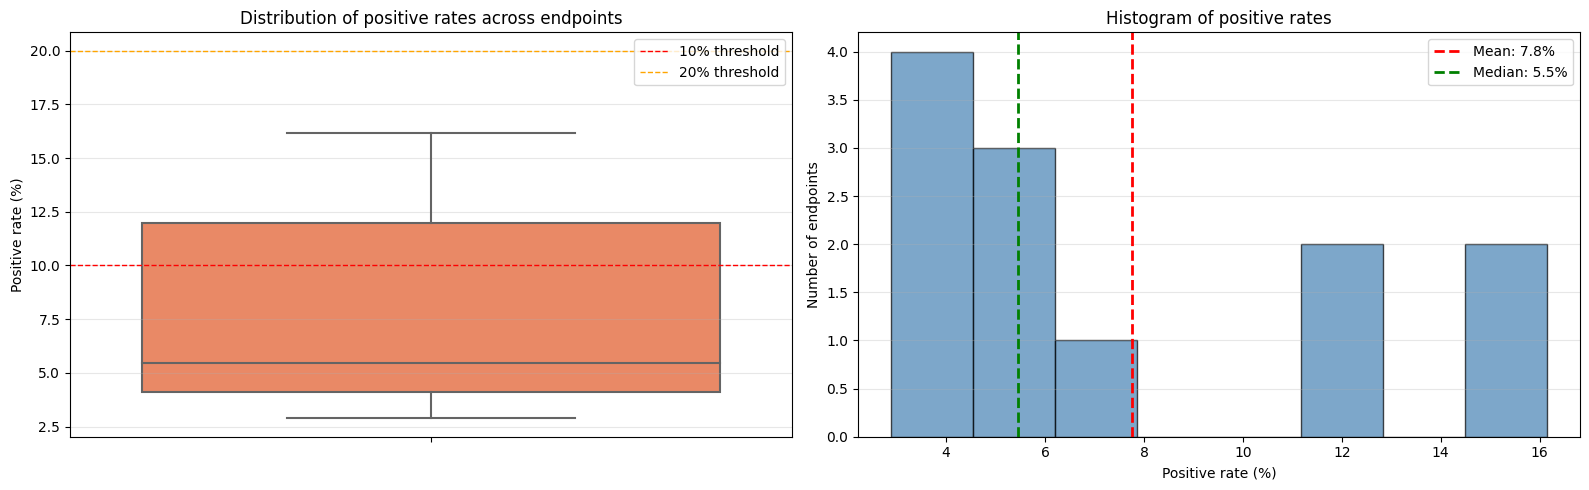

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


sns.boxplot(y=imbalance_view['Positive_Pct'], ax=axes[0], color='coral')
axes[0].set_ylabel('Positive rate (%)')
axes[0].set_title('Distribution of positive rates across endpoints')
axes[0].axhline(10, color='red', linestyle='--', linewidth=1, label='10% threshold')
axes[0].axhline(20, color='orange', linestyle='--', linewidth=1, label='20% threshold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


axes[1].hist(imbalance_view['Positive_Pct'], bins=8, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(imbalance_view['Positive_Pct'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {imbalance_view['Positive_Pct'].mean():.1f}%")
axes[1].axvline(imbalance_view['Positive_Pct'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {imbalance_view['Positive_Pct'].median():.1f}%")
axes[1].set_xlabel('Positive rate (%)')
axes[1].set_ylabel('Number of endpoints')
axes[1].set_title('Histogram of positive rates')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

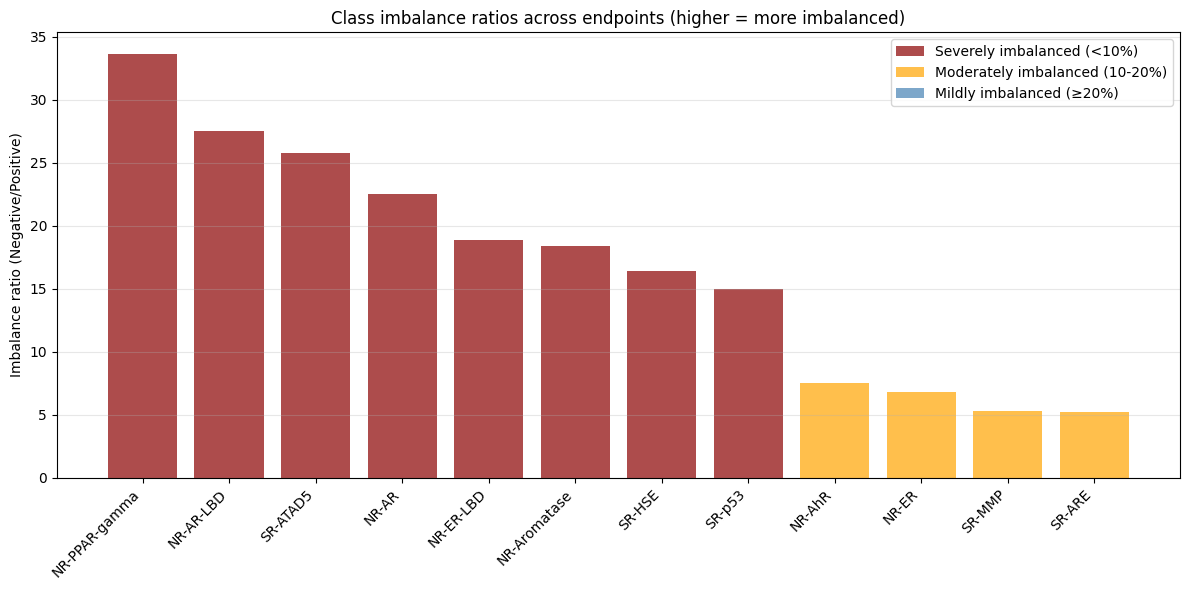


Top 3 most imbalanced endpoints:
  NR-PPAR-gamma: 33.7x (6264 negatives vs 186 positives)
  NR-AR-LBD: 27.5x (6521 negatives vs 237 positives)
  SR-ATAD5: 25.8x (6808 negatives vs 264 positives)


In [29]:

fig, ax = plt.subplots(figsize=(12, 6))


sorted_by_ratio = imbalance_view.sort_values('Imbalance_Ratio', ascending=False)
colors = ['darkred' if x < 10 else 'orange' if x < 20 else 'steelblue' 
          for x in sorted_by_ratio['Positive_Pct']]

bars = ax.bar(range(len(sorted_by_ratio)), sorted_by_ratio['Imbalance_Ratio'], color=colors, alpha=0.7)
ax.set_xticks(range(len(sorted_by_ratio)))
ax.set_xticklabels(sorted_by_ratio['Endpoint'], rotation=45, ha='right')
ax.set_ylabel('Imbalance ratio (Negative/Positive)')
ax.set_title('Class imbalance ratios across endpoints (higher = more imbalanced)')
ax.grid(axis='y', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkred', alpha=0.7, label='Severely imbalanced (<10%)'),
    Patch(facecolor='orange', alpha=0.7, label='Moderately imbalanced (10-20%)'),
    Patch(facecolor='steelblue', alpha=0.7, label='Mildly imbalanced (≥20%)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print("\nTop 3 most imbalanced endpoints:")
for idx, row in sorted_by_ratio.head(3).iterrows():
    print(f"  {row['Endpoint']}: {_format_ratio(row['Imbalance_Ratio'])} "
          f"({row['Negative']:.0f} negatives vs {row['Positive']:.0f} positives)")

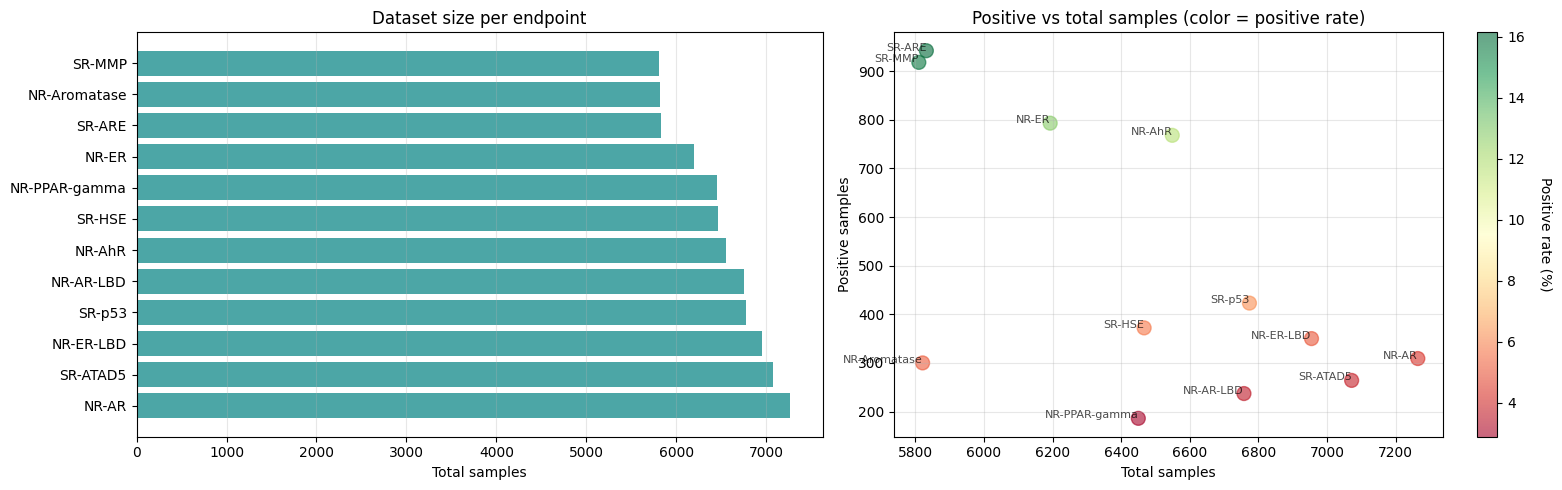


Dataset size range: 5810 to 7265 samples
Average dataset size: 6496 samples
Total samples across all endpoints: 77946


In [30]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total samples per endpoint
sorted_by_size = imbalance_view.sort_values('Total', ascending=False)
axes[0].barh(range(len(sorted_by_size)), sorted_by_size['Total'], color='teal', alpha=0.7)
axes[0].set_yticks(range(len(sorted_by_size)))
axes[0].set_yticklabels(sorted_by_size['Endpoint'])
axes[0].set_xlabel('Total samples')
axes[0].set_title('Dataset size per endpoint')
axes[0].grid(axis='x', alpha=0.3)

# Positive vs total samples scatter
axes[1].scatter(imbalance_view['Total'], imbalance_view['Positive'], 
               s=100, alpha=0.6, c=imbalance_view['Positive_Pct'], cmap='RdYlGn')
for idx, row in imbalance_view.iterrows():
    axes[1].annotate(row['Endpoint'], (row['Total'], row['Positive']), 
                    fontsize=8, alpha=0.7, ha='right')
axes[1].set_xlabel('Total samples')
axes[1].set_ylabel('Positive samples')
axes[1].set_title('Positive vs total samples (color = positive rate)')
axes[1].grid(alpha=0.3)

# Add colorbar
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Positive rate (%)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print(f"\nDataset size range: {imbalance_view['Total'].min():.0f} to {imbalance_view['Total'].max():.0f} samples")
print(f"Average dataset size: {imbalance_view['Total'].mean():.0f} samples")
print(f"Total samples across all endpoints: {imbalance_view['Total'].sum():.0f}")

### Key Insights & Recommendations

Based on the class imbalance analysis above:

1. **Severity of Imbalance**: Most Tox21 endpoints are highly imbalanced, with positive (toxic) samples representing a small minority.

2. **Potential Strategies to Address Imbalance**:
   - **Class weighting**: Assign higher weights to positive samples during training
   - **Oversampling**: SMOTE or ADASYN for synthetic positive samples
   - **Undersampling**: Random or Tomek links for majority class
   - **Ensemble methods**: Balanced random forests or EasyEnsemble
   - **Threshold tuning**: Adjust classification threshold based on validation performance

3. **Evaluation Metrics**: 
   - Accuracy is **not appropriate** for imbalanced datasets
   - Use: **ROC-AUC**, **PR-AUC**, **F1-score**, **Matthews correlation coefficient**
   - Focus on **recall** (sensitivity) to minimize false negatives in toxicity prediction

4. **Cross-validation**: Stratified k-fold ensures each fold maintains class distribution.

ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle', 'grid_solid_joinstyle', 'grid_transform', 'grid_url

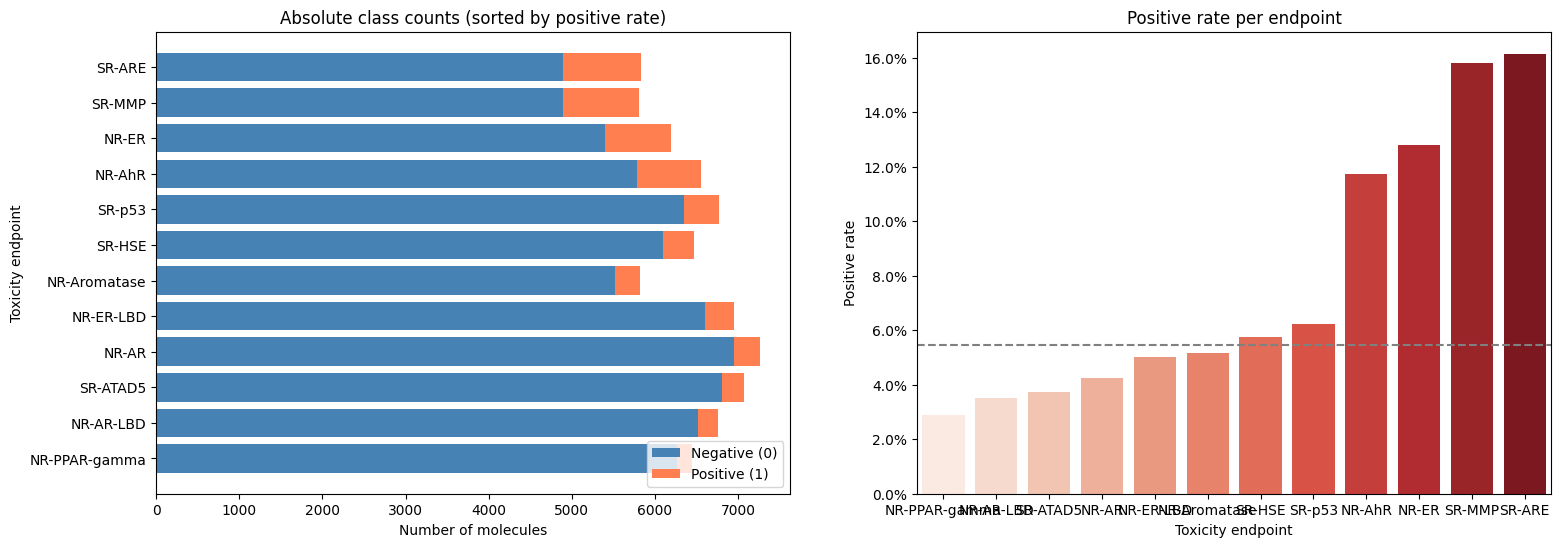

In [31]:

sorted_counts = summary_df.sort_values('Positive_Rate').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Horizontal stacked bars for absolute counts
axes[0].barh(sorted_counts['Endpoint'], sorted_counts['Negative'], color='steelblue', label='Negative (0)')
axes[0].barh(sorted_counts['Endpoint'], sorted_counts['Positive'], left=sorted_counts['Negative'], color='coral', label='Positive (1)')
axes[0].set_xlabel('Number of molecules')
axes[0].set_ylabel('Toxicity endpoint')
axes[0].set_title('Absolute class counts (sorted by positive rate)')
axes[0].legend(loc='lower right')

# Positive rate bar chart
sns.barplot(data=sorted_counts, x='Endpoint', y='Positive_Rate', ax=axes[1], palette='Reds')
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[1].axhline(sorted_counts['Positive_Rate'].median(), color='gray', linestyle='--', label='Median positive rate')
axes[1].set_xlabel('Toxicity endpoint')
axes[1].set_ylabel('Positive rate')
axes[1].set_title('Positive rate per endpoint')
axes[1].tick_params(axis='x', rotation=45, ha='right')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

most_imbalanced = sorted_counts.iloc[0]
least_imbalanced = sorted_counts.iloc[-1]
print(
    f"Most imbalanced: {most_imbalanced['Endpoint']} with {most_imbalanced['Positive_Rate']*100:.1f}% positives "
    f"({_format_ratio(most_imbalanced['Imbalance_Ratio'])} more negatives)."
 )
print(
    f"Closest to balanced: {least_imbalanced['Endpoint']} with {least_imbalanced['Positive_Rate']*100:.1f}% positives."
 )

## 2. Scaffold-Based Splitting

Scaffold splitting ensures structurally different molecules are in different splits, preventing data leakage and providing a more realistic evaluation.

In [ ]:

def generate_scaffold(smiles, include_chirality=False):
    """Generate Bemis-Murcko scaffold for a molecule."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=include_chirality)
        return scaffold
    except:
        return None

def scaffold_split(smiles_list, train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    Split dataset based on molecular scaffolds.
    Ensures structurally different molecules are in different subsets.
    """
    np.random.seed(seed)
    
    # Generate scaffolds for all molecules
    scaffolds = defaultdict(list)
    for idx, smiles in enumerate(smiles_list):
        scaffold = generate_scaffold(smiles)
        if scaffold is not None:
            scaffolds[scaffold].append(idx)
        else:
            scaffolds[f"invalid_{idx}"].append(idx)
    
    # Sort scaffolds by size (descending)
    scaffold_sets = sorted(scaffolds.items(), key=lambda x: len(x[1]), reverse=True)
    
    # Distribute scaffolds into train/val/test sets
    train_idx, val_idx, test_idx = [], [], []
    train_size, val_size = 0, 0
    total_size = len(smiles_list)
    
    for scaffold, indices in scaffold_sets:
        train_prop = train_size / total_size if total_size > 0 else 0
        val_prop = val_size / total_size if total_size > 0 else 0
        
        if train_prop < train_ratio:
            train_idx.extend(indices)
            train_size += len(indices)
        elif val_prop < val_ratio:
            val_idx.extend(indices)
            val_size += len(indices)
        else:
            test_idx.extend(indices)
    
    return train_idx, val_idx, test_idx

# Example: Split first dataset
example_df = load_dataset('NR-AhR').dropna(subset=['NR-AhR'])
train_idx, val_idx, test_idx = scaffold_split(example_df['SMILES'].tolist())
print(f"Example split for NR-AhR:")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(example_df)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} ({len(val_idx)/len(example_df)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(example_df)*100:.1f}%)")

[20:32:30] WARNING: not removing hydrogen atom without neighbors


Example split for NR-AhR:
  Train: 5240 (80.0%)
  Val:   655 (10.0%)
  Test:  654 (10.0%)


## 3. ECFP4 Fingerprint Encoding

Extended Connectivity Fingerprints (ECFP4) are circular topological fingerprints used for encoding molecules for baseline ML models (KNN, NN, RF, SVM, XGBoost).

In [ ]:
# ============================================================================
# ECFP4 FINGERPRINT ENCODER
# ============================================================================
def smiles_to_ecfp4(smiles, radius=2, n_bits=2048):
    """Convert SMILES to ECFP4 fingerprint."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        return np.array(fp)
    except:
        return None

def encode_dataset(smiles_list, radius=2, n_bits=2048):
    """Encode a list of SMILES to ECFP4 fingerprints."""
    fingerprints = []
    valid_indices = []
    
    for idx, smiles in enumerate(smiles_list):
        fp = smiles_to_ecfp4(smiles, radius, n_bits)
        if fp is not None:
            fingerprints.append(fp)
            valid_indices.append(idx)
    
    return np.array(fingerprints), valid_indices

# Example: Encode a molecule
example_smiles = "CCO"  # Ethanol
fp = smiles_to_ecfp4(example_smiles)
print(f"ECFP4 fingerprint for ethanol ({example_smiles}):")
print(f"  Length: {len(fp)}")
print(f"  Non-zero bits: {np.sum(fp)}")
print(f"  First 50 bits: {fp[:50]}")

ECFP4 fingerprint for ethanol (CCO):
  Length: 2048
  Non-zero bits: 6
  First 50 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 4. Molecule to Graph Conversion

Convert SMILES to graph representations for GCN. Each molecule becomes a graph with:
- **Nodes**: Atoms with 74 features (atom type, degree, charge, etc.)
- **Edges**: Chemical bonds between atoms

In [ ]:
# ============================================================================
# MOLECULE TO GRAPH CONVERTER (for GCN)
# ============================================================================
# Atom type one-hot encoding (44 common elements)
ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 
              'Ca', 'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl', 'Yb', 'Sb', 
              'Sn', 'Ag', 'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H', 'Li', 'Ge', 
              'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr', 'Cr', 'Pt', 'Hg', 'Pb']

def get_atom_features(atom):
    """Extract 74-dimensional features for a single atom."""
    features = []
    
    # 1. Atom type (one-hot, 44 dims)
    atom_type = atom.GetSymbol()
    atom_type_enc = [1 if atom_type == t else 0 for t in ATOM_TYPES]
    atom_type_enc.append(1 if atom_type not in ATOM_TYPES else 0)  # Unknown
    features.extend(atom_type_enc[:44])
    
    # 2. Degree (one-hot, 11 dims)
    degree = min(atom.GetDegree(), 10)
    degree_enc = [1 if i == degree else 0 for i in range(11)]
    features.extend(degree_enc)
    
    # 3. Formal charge (one-hot, 5 dims)
    charge_map = {-1: 0, -2: 1, 1: 2, 2: 3, 0: 4}
    charge = atom.GetFormalCharge()
    charge_enc = [0] * 5
    if charge in charge_map:
        charge_enc[charge_map[charge]] = 1
    features.extend(charge_enc)
    
    # 4. Number of Hs (one-hot, 5 dims)
    num_hs = min(atom.GetTotalNumHs(), 4)
    hs_enc = [1 if i == num_hs else 0 for i in range(5)]
    features.extend(hs_enc)
    
    # 5. Hybridization (one-hot, 5 dims)
    hyb_types = [Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
                 Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
                 Chem.rdchem.HybridizationType.SP3D2]
    hyb = atom.GetHybridization()
    hyb_enc = [1 if hyb == h else 0 for h in hyb_types]
    features.extend(hyb_enc)
    
    # 6-8. Binary features (4 dims)
    features.append(int(atom.GetIsAromatic()))
    features.append(int(atom.IsInRing()))
    features.append(int(atom.GetChiralTag() != Chem.rdchem.ChiralType.CHI_UNSPECIFIED))
    features.append(0)  # Padding
    
    return np.array(features[:74], dtype=np.float32)

def smiles_to_graph(smiles):
    """Convert SMILES to graph representation."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        num_atoms = mol.GetNumAtoms()
        
        # Extract node features (N x 74)
        node_features = [get_atom_features(atom) for atom in mol.GetAtoms()]
        feature_matrix = np.array(node_features, dtype=np.float32)
        
        # Build adjacency matrix
        adjacency = np.zeros((num_atoms, num_atoms), dtype=np.int32)
        edges_src, edges_dst = [], []
        
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edges_src.extend([i, j])
            edges_dst.extend([j, i])
            adjacency[i, j] = adjacency[j, i] = 1
        
        return {
            'feature_matrix': feature_matrix,
            'adjacency_matrix': adjacency,
            'edges': (edges_src, edges_dst),
            'num_atoms': num_atoms,
            'smiles': smiles
        }
    except:
        return None

# Example: Convert a molecule
graph = smiles_to_graph("c1ccccc1")  # Benzene
print(f"Graph representation for benzene:")
print(f"  Atoms: {graph['num_atoms']}")
print(f"  Feature matrix shape: {graph['feature_matrix'].shape}")
print(f"  Adjacency matrix shape: {graph['adjacency_matrix'].shape}")

Graph representation for benzene:
  Atoms: 6
  Feature matrix shape: (6, 74)
  Adjacency matrix shape: (6, 6)


## 5. Process and Cache All Datasets

Process all 12 toxicity endpoints and save the preprocessed data for training.

In [ ]:
# ============================================================================
# PROCESS ALL DATASETS
# ============================================================================
def process_dataset(toxicity_name, save_cache=True):
    """Process a single toxicity dataset: split, encode, and cache."""
    print(f"\nProcessing {toxicity_name}...")
    
    # Load data
    df = load_dataset(toxicity_name)
    df_clean = df.dropna(subset=[toxicity_name])
    
    smiles_list = df_clean['SMILES'].tolist()
    labels = df_clean[toxicity_name].values.astype(int)
    
    # Scaffold split
    train_idx, val_idx, test_idx = scaffold_split(smiles_list)
    
    # Encode to ECFP4
    fingerprints, valid_idx = encode_dataset(smiles_list)
    
    # Filter indices to valid molecules
    idx_to_fp = {valid_idx[i]: i for i in range(len(valid_idx))}
    train_idx = [i for i in train_idx if i in idx_to_fp]
    val_idx = [i for i in val_idx if i in idx_to_fp]
    test_idx = [i for i in test_idx if i in idx_to_fp]
    
    result = {
        'dataset_name': toxicity_name,
        'train': {
            'X': fingerprints[[idx_to_fp[i] for i in train_idx]],
            'y': labels[train_idx],
            'smiles': [smiles_list[i] for i in train_idx]
        },
        'val': {
            'X': fingerprints[[idx_to_fp[i] for i in val_idx]],
            'y': labels[val_idx],
            'smiles': [smiles_list[i] for i in val_idx]
        },
        'test': {
            'X': fingerprints[[idx_to_fp[i] for i in test_idx]],
            'y': labels[test_idx],
            'smiles': [smiles_list[i] for i in test_idx]
        }
    }
    
    print(f"  Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
    
    # Save to cache
    if save_cache:
        os.makedirs(os.path.join(CACHE_DIR, toxicity_name), exist_ok=True)
        cache_path = os.path.join(CACHE_DIR, toxicity_name, 'splits.pkl')
        with open(cache_path, 'wb') as f:
            pickle.dump(result, f)
        print(f"  Cached to: {cache_path}")
    
    return result

# Process first dataset as example (uncomment to process all)
result = process_dataset('NR-AhR')
print(f"\n✓ Dataset processed successfully!")


Processing NR-AhR...


[20:32:58] WARNING: not removing hydrogen atom without neighbors
[20:33:01] WARNING: not removing hydrogen atom without neighbors
[20:33:01] WARNING: not removing hydrogen atom without neighbors


  Train: 5240, Val: 655, Test: 654
  Cached to: ../Data/cache\NR-AhR\splits.pkl

✓ Dataset processed successfully!


In [ ]:
# ============================================================================
# PROCESS ALL DATASETS (uncomment to run)
# ============================================================================
# all_results = {}
# for endpoint in TOXICITY_ENDPOINTS:
#     all_results[endpoint] = process_dataset(endpoint)
# print(f"\n✓ All {len(TOXICITY_ENDPOINTS)} datasets processed!")

## 6. Visualization

Visualize class distribution and example molecules.

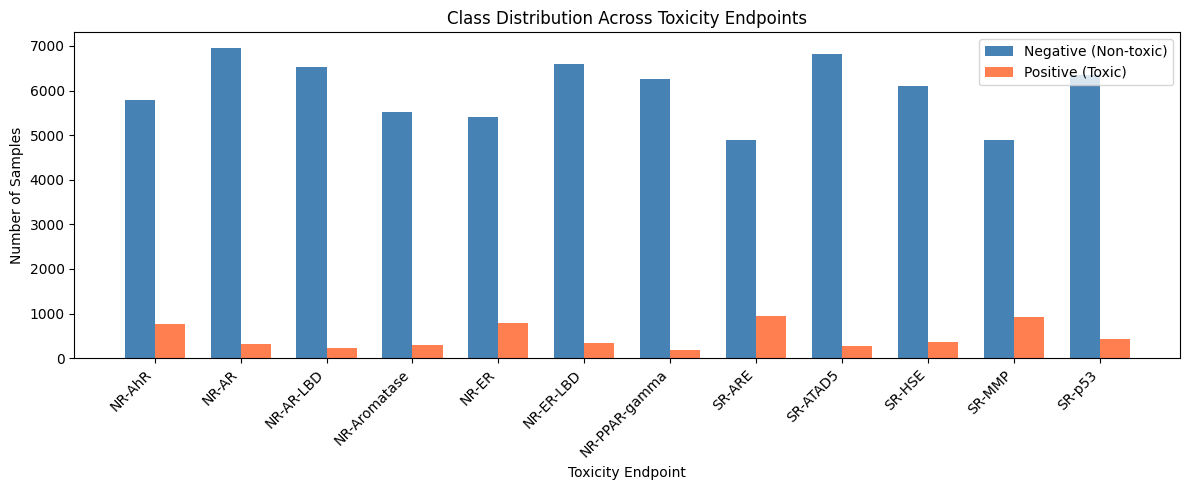

Note: The datasets are imbalanced - positive (toxic) samples are minority class.


In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

endpoints = [d['Endpoint'] for d in dataset_summary]
pos_counts = [d['Positive'] for d in dataset_summary]
neg_counts = [d['Negative'] for d in dataset_summary]

x = np.arange(len(endpoints))
width = 0.35

bars1 = ax.bar(x - width/2, neg_counts, width, label='Negative (Non-toxic)', color='steelblue')
bars2 = ax.bar(x + width/2, pos_counts, width, label='Positive (Toxic)', color='coral')

ax.set_xlabel('Toxicity Endpoint')
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution Across Toxicity Endpoints')
ax.set_xticks(x)
ax.set_xticklabels(endpoints, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

print("Note: The datasets are imbalanced - positive (toxic) samples are minority class.")